<a href="https://colab.research.google.com/github/SSNEGI05/portfolio_analysis/blob/main/Failure_of_Normal_Risk_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook, we are going to prove why the "Normal Distribution" can be a dangerous lie in the Indian market.
1. Concept: The "Tail Risk" GapStandard risk models **(Parametric VaR)** assume the world is a Bell Curve. But we already saw that Nifty has an Excess Kurtosis of 22+. This means the "Tails" are much heavier than the model thinks.
2. Mathematical Rigor: Parametric vs. Historical VaR
   
   We will compare two ways of calculating Value at Risk (VaR):
   
   Parametric VaR: $VaR = \mu + z \sigma$. This is the "Ideal World" model.
   
   Historical VaR: This is the "Real World" model. It simply looks at the 5th percentile of actual past returns, which includes the **crashes**.

In [10]:
# ==============================================================================
# PROJECT: THE VAR LIE - ANALYZING FAT TAILS & MODEL RISK
# Goal: Compare Normal vs. Historical Value at Risk (VaR)
# ==============================================================================

import yfinance as yf
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters - Adjust these for your analysis
ticker = "RELIANCE.NS"
investment_amt = 1000000  # ₹10 Lakhs
confidence_level = 0.99   # 95% confidence or 99% Confidence

# Fetching 10 years of data to capture 'Fat Tail' events (like 2020)
data = yf.download(ticker, start="2016-01-01", end="2026-03-01", auto_adjust=True)
returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()

print(f"Data for {ticker} fetched. Ready for Risk Analysis.")

[*********************100%***********************]  1 of 1 completed

Data for RELIANCE.NS fetched. Ready for Risk Analysis.


This cell calculates the **Parametric VaR **(the theoretical model) and the **Historical VaR** (the real-world reality). We then calculate the "Risk Gap" to see how much the normal distribution is underestimating your potential losses.

In [11]:
# ------------------------------------------------------------------------------
# CELL 2: DYNAMIC RISK GAP
# ------------------------------------------------------------------------------

# 1. PARAMETRIC VaR (The "Normal Distribution" Model)
mu = returns.mean()
sigma = returns.std()
z_score = norm.ppf(1 - confidence_level)

# Ensure we have scalars (single numbers) for formatting
# We use .iloc[0] because 'returns' is a DataFrame from yfinance
p_var_pct = (mu + z_score * sigma).iloc[0]
parametric_var = p_var_pct * investment_amt

# 2. HISTORICAL VaR (The "Real World" Model)
# np.percentile looks at actual history, including 'Fat Tail' crashes
historical_var_pct = np.percentile(returns, (1 - confidence_level) * 100)
historical_var = historical_var_pct * investment_amt

# 3. DYNAMIC LOGIC FOR ANALYSIS
risk_gap = abs(historical_var) - abs(parametric_var)
error_pct = (risk_gap / abs(parametric_var)) * 100

print(f"--- Automated Risk Report for {ticker} ---")
print(f"Investment: ₹{investment_amt/100000:,.1f}L | Confidence: {confidence_level*100}%")
print(f"Normal Model VaR:      ₹{abs(parametric_var):,.2f}")
print(f"Actual Historical VaR:  ₹{abs(historical_var):,.2f}")
print("-" * 45)

if risk_gap > 0:
    print(f"RESULT: ⚠️ MODEL UNDERESTIMATION")
    print(f"The Normal Distribution is missing ₹{risk_gap:,.2f} of 'Tail Risk'.")
    print(f"Model Error: {error_pct:.2f}% (Danger Zone detected)")
else:
    print(f"RESULT: ✅ MODEL CONSERVATISM")
    print(f"At this level, the Normal model is OVERESTIMATING risk by ₹{abs(risk_gap):,.2f}.")
    print(f"Model Error: {abs(error_pct):.2f}% (Safe Buffer)")

print("\nADVICE: If the error is negative at 95% but positive at 99%, the asset has 'Hidden Fat Tails'.")

--- Automated Risk Report for RELIANCE.NS ---
Investment: ₹10.0L | Confidence: 99.0%
Normal Model VaR:      ₹38,717.49
Actual Historical VaR:  ₹39,962.66
---------------------------------------------
RESULT: ⚠️ MODEL UNDERESTIMATION
The Normal Distribution is missing ₹1,245.17 of 'Tail Risk'.
Model Error: 3.22% (Danger Zone detected)

ADVICE: If the error is negative at 95% but positive at 99%, the asset has 'Hidden Fat Tails'.


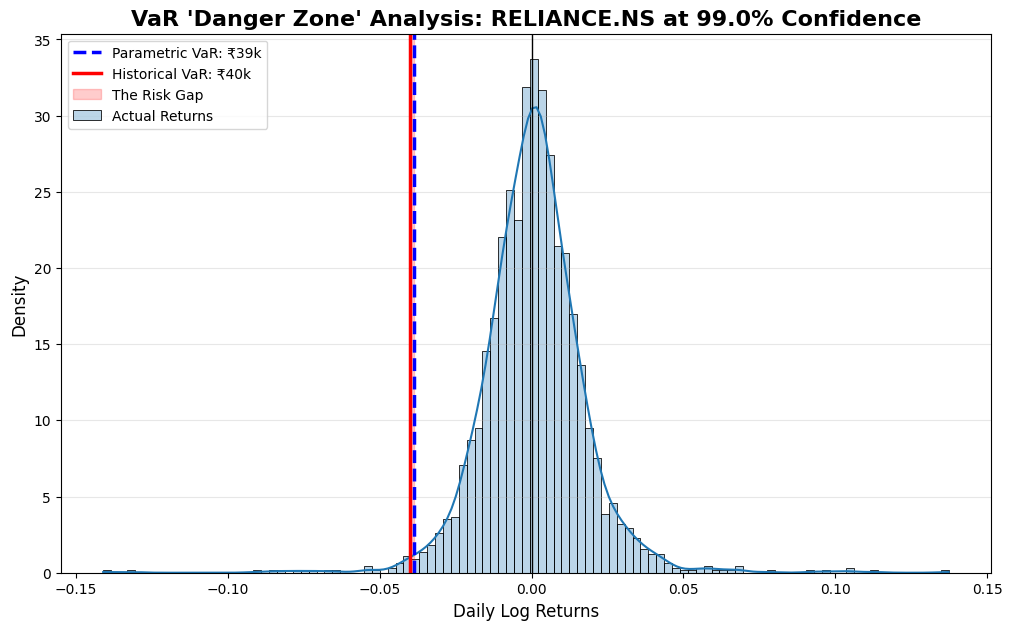

In [12]:
# ------------------------------------------------------------------------------
# CELL 3: VISUALIZING
# ------------------------------------------------------------------------------

plt.figure(figsize=(12, 7))

# 1. Plot the actual return distribution (Histogram + KDE)
sns.histplot(returns, kde=True, color='gray', alpha=0.3, stat="density", label='Actual Returns')

# 2. Add the Parametric VaR Line (The "Normal" Theory)
plt.axvline(p_var_pct, color='blue', linestyle='--', linewidth=2.5,
            label=f'Parametric VaR: ₹{abs(parametric_var/1000):,.0f}k')

# 3. Add the Historical VaR Line (The "Real" History)
plt.axvline(historical_var_pct, color='red', linestyle='-', linewidth=2.5,
            label=f'Historical VaR: ₹{abs(historical_var/1000):,.0f}k')

# 4. Highlight the 'Danger Zone' (The Gap)
# We use min/max to ensure the shading covers the area between the two lines
v1, v2 = p_var_pct, historical_var_pct
plt.axvspan(min(v1, v2), max(v1, v2), color='red', alpha=0.2, label='The Risk Gap')

# 5. Formatting for a Professional Report
plt.title(f"VaR 'Danger Zone' Analysis: {ticker} at {confidence_level*100}% Confidence", fontsize=16, fontweight='bold')
plt.xlabel("Daily Log Returns", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.axvline(0, color='black', lw=1) # Add a center line at 0% return
plt.legend(loc='upper left', fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.show()